In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [30]:
train_df = pd.read_csv("/content/Training.csv")
test_df = pd.read_csv("/content/Testing.csv")
train_df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [31]:
train_df = train_df.drop(columns=["Unnamed: 133"], errors="ignore")
train_df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [32]:
print(f"Training Data → Rows: {train_df.shape[0]}, Columns: {train_df.shape[1]}")
print(f"Testing Data → Rows: {test_df.shape[0]}, Columns: {test_df.shape[1]}")

Training Data → Rows: 4920, Columns: 133
Testing Data → Rows: 42, Columns: 133


In [33]:
train_df.count()
test_df.count()
train_df["prognosis"].value_counts()

,count
prognosis,
Fungal infection,120
Allergy,120
GERD,120
Chronic cholestasis,120
Drug Reaction,120
Peptic ulcer diseae,120
AIDS,120
Diabetes,120
Gastroenteritis,120


In [34]:
train_df.isnull().sum()

,0
itching,0
skin_rash,0
nodal_skin_eruptions,0
continuous_sneezing,0
shivering,0
...,...
inflammatory_nails,0
blister,0
red_sore_around_nose,0
yellow_crust_ooze,0


In [35]:
train_df.dtypes

,0
itching,int64
skin_rash,int64
nodal_skin_eruptions,int64
continuous_sneezing,int64
shivering,int64
...,...
inflammatory_nails,int64
blister,int64
red_sore_around_nose,int64
yellow_crust_ooze,int64


In [36]:
X=train_df.drop("prognosis",axis=1)
y=train_df["prognosis"]


In [37]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(3444, 132) (3444,)
(1476, 132) (1476,)


In [38]:
rf=RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [39]:
rf_pred = rf.predict(X_test)
print("RF Accuracy:",accuracy_score(y_test,rf_pred))
print("Train Accuracy",rf.score(X_train,y_train))
print("Test Accuracy:",rf.score(X_test,y_test))
print(classification_report(y_test,rf_pred ))

RF Accuracy: 1.0
Train Accuracy 1.0
Test Accuracy: 1.0
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        32
                                   AIDS       1.00      1.00      1.00        39
                                   Acne       1.00      1.00      1.00        41
                    Alcoholic hepatitis       1.00      1.00      1.00        36
                                Allergy       1.00      1.00      1.00        35
                              Arthritis       1.00      1.00      1.00        36
                       Bronchial Asthma       1.00      1.00      1.00        44
                   Cervical spondylosis       1.00      1.00      1.00        32
                            Chicken pox       1.00      1.00      1.00        35
                    Chronic cholestasis       1.00      1.00      1.00        30
                            Common Cold       1.00   

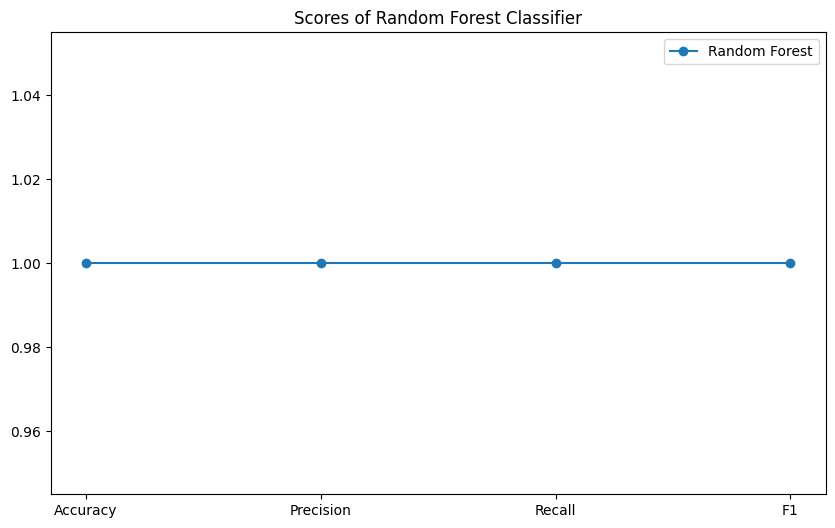

In [41]:
accuracy = accuracy_score(y_test, rf_pred)
precision = precision_score(y_test, rf_pred, average='weighted')
recall = recall_score(y_test, rf_pred, average='weighted')
f1 = f1_score(y_test, rf_pred, average='weighted')

plt.figure(figsize=(10,6))

x1 = np.array(['Accuracy', 'Precision', 'Recall', 'F1'])

y1 = np.array([accuracy, precision, recall, f1])

plt.plot(x1, y1, marker='o', label='Random Forest')

plt.title("Scores of Random Forest Classifier")

plt.legend()

plt.show()

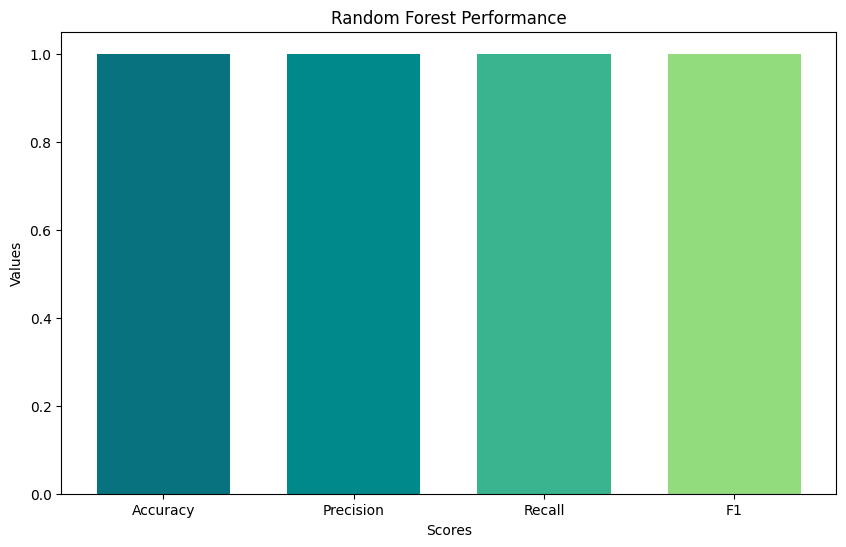

In [42]:


left = [1, 2, 3, 4]

plt.figure(figsize=(10,6))

height = [accuracy, precision, recall, f1]

tick_label = ['Accuracy', 'Precision', 'Recall', 'F1']

plt.bar(
    left,
    height,
    tick_label=tick_label,
    width=0.7,
    color=['#08737f', '#00898a', '#39b48e', '#92dc7e']
)

plt.xlabel('Scores')

plt.ylabel('Values')

plt.title('Random Forest Performance')

plt.show()

Confusion Matrix:
[[32  0  0 ...  0  0  0]
 [ 0 39  0 ...  0  0  0]
 [ 0  0 41 ...  0  0  0]
 ...
 [ 0  0  0 ... 36  0  0]
 [ 0  0  0 ...  0 37  0]
 [ 0  0  0 ...  0  0 39]]


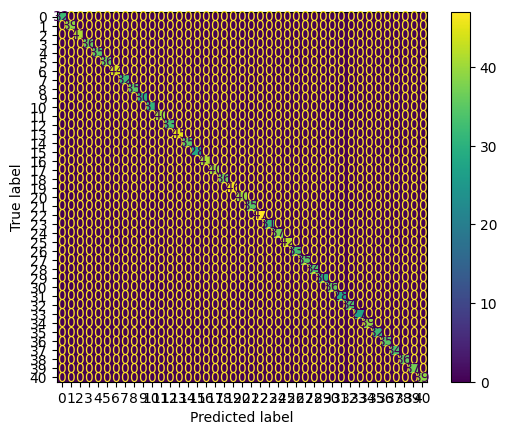

In [46]:
rf_pred=rf.predict(X_test)
cm=confusion_matrix(y_test,rf_pred)
print("Confusion Matrix:")
print(cm)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Model training

In [ ]:
pickle.dump(rf, open("final_model.pkl", "wb"))


In [ ]:
import numpy as np
import pickle

# Load Model
model = pickle.load(open('final_model.pkl', 'rb'))

print("Enter symptoms (0 or 1):")

user_input = []

for col in X_train.columns:
    val = int(input(f"{col}: "))
    user_input.append(val)

# Convert to numpy array
X_new = np.array([user_input])

# Predict disease
prediction = model.predict(X_new)

print("Predicted Disease:", prediction[0])

Enter symptoms (0 or 1):
itching: 1
skin_rash: 1
nodal_skin_eruptions: 1
continuous_sneezing: 1
shivering: 0
chills: 0
joint_pain: 0
stomach_pain: 0
acidity: 0
ulcers_on_tongue: 0
muscle_wasting: 0
vomiting: 0
burning_micturition: 0
spotting_ urination: 0
fatigue: 0
weight_gain: 0
anxiety: 0
cold_hands_and_feets: 0
mood_swings: 0
weight_loss: 0
restlessness: 0
lethargy: 0
patches_in_throat: 0
irregular_sugar_level: 0
cough: 0
high_fever: 0
sunken_eyes: 0
breathlessness: 0
sweating: 0
dehydration: 0
indigestion: 0
headache: 0
yellowish_skin: 0
dark_urine: 0
nausea: 0
loss_of_appetite: 0
pain_behind_the_eyes: 0
back_pain: 0
constipation: 0
abdominal_pain: 0
diarrhoea: 0
mild_fever: 0
yellow_urine: 0
yellowing_of_eyes: 0
acute_liver_failure: 0
fluid_overload: 0
swelling_of_stomach: 0
swelled_lymph_nodes: 0
malaise: 0
blurred_and_distorted_vision: 0
phlegm: 0
throat_irritation: 0
redness_of_eyes: 0
sinus_pressure: 0
runny_nose: 0
congestion: 0
chest_pain: 0
weakness_in_limbs: 0
